In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

In [9]:
N = 10000
X,t = make_swiss_roll(n_samples=N, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

X=torch.tensor(X, dtype=torch.float32)

In [10]:
sigma_list = [1, 0.5, 0.2, 0.1, 0.05, 0.02]


all_x_noisy = []
all_sigma = []
all_target = []

for sigma in sigma_list:
    noise = torch.randn_like(X)
    x_noisy = X + sigma*noise
    sigma_col = torch.full((len(X), 1), sigma)

    target = -noise / sigma

    all_x_noisy.append(x_noisy)
    all_sigma.append(sigma_col)
    all_target.append(target)

x_noisy = torch.cat(all_x_noisy, dim=0)
sigmas = torch.cat(all_sigma, dim=0)
targets = torch.cat(all_target, dim=0)



In [11]:
def train_model(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  num_epochs = 5000      
):
    dataset = TensorDataset(x_noisy, sigmas, targets)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(3,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    
    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for x_batch, sigma_batch, target_batch in loader:
            
            model_input = torch.cat([x_batch, sigma_batch], dim=1)
            score_pred = model(model_input)

            loss_per_sample = ((score_pred-target_batch)**2).sum(dim=1)


            noise_weights = sigma_batch.squeeze()**2

            loss = (loss_per_sample*noise_weights).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return model, loss_history


In [12]:
model, losses = train_model()

In [13]:
model.eval()

with torch.no_grad():

    x = torch.randn(10000, 2)
    num_steps_each_sigma = 500
    eta = 1e-4


    for sigma in sigma_list:
        sigma_tensor = torch.full((x.shape[0], 1), sigma) 
     
        for _ in range(num_steps_each_sigma):

            model_input = torch.cat([x, sigma_tensor], dim=1)

            score = model(model_input)

            noise = torch.randn_like(x)

            x = x + eta * score + np.sqrt(2 * eta) * noise


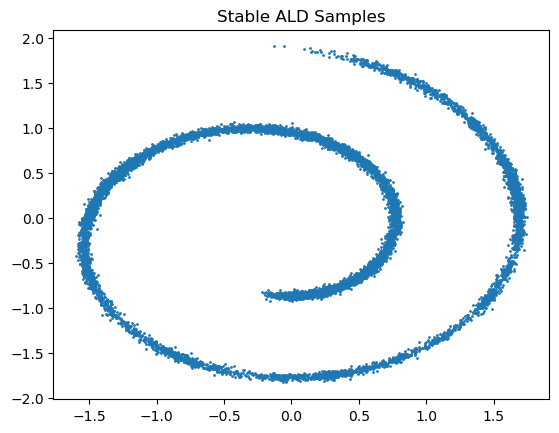

In [14]:
samples = x.detach().cpu().numpy()

plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.title("Stable ALD Samples")
plt.show()

Visually, the generated samples are more refined and closer to the original in this case, when compared to the single-noise level.
It is worth mentioning that this test code does not use the simga_max and sigma_min choosing strategy from the paper, which has been addressed in the "efficient" version of the code.

In [17]:
bins = 100
H_real, xedges, yedges = np.histogram2d(
    X[:,0], X[:,1],
    bins=bins,
    density=True
)


H_generated, _, _ = np.histogram2d(
    samples[:,0],
    samples[:,1],
    bins=[xedges, yedges],   # Use the SAME grid
    density=True
)

difference = np.sum(np.abs(H_real - H_generated))
print(difference)


740.4203573824419


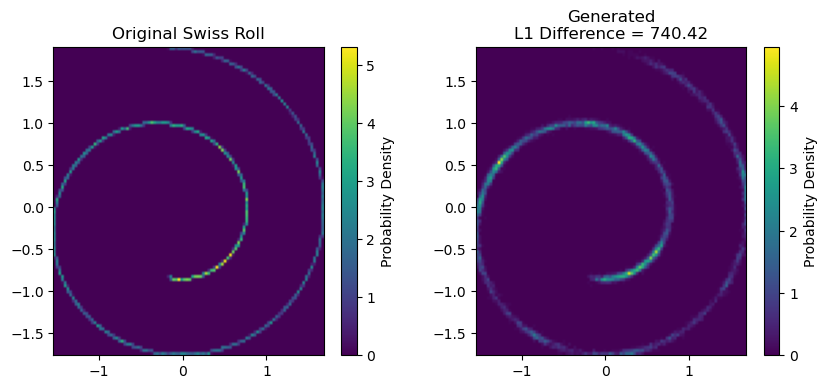

In [18]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1= ax[0].imshow(
    H_real.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[0].set_title("Original Swiss Roll")

im2=ax[1].imshow(
    H_generated.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[1].set_title(f"Generated\nL1 Difference = {difference:.2f}")

fig.colorbar(im1, ax=ax[0], label="Probability Density")
fig.colorbar(im2, ax=ax[1], label="Probability Density")
plt.show()

The L1 difference has reduced from 1214 to 740 when we switch from single to multi-noise levels and annealed Langevin sampling